<a href="https://colab.research.google.com/github/diyam08/AI-Travel-Analyst/blob/main/source_code_fin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn streamlit plotly shap pyngrok

import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import shap
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')

os.makedirs('model_artifacts', exist_ok=True)
os.makedirs('viz_outputs', exist_ok=True)
print("Libraries imported and directories initialized!")

Libraries imported and directories initialized!


In [5]:
from google.colab import files

uploaded = files.upload()

Saving flight_pricing_dataset.csv to flight_pricing_dataset.csv


In [6]:

df_raw = pd.read_csv('flight_pricing_dataset.csv')
df_raw.columns = df_raw.columns.str.strip()


df = df_raw.dropna(subset=['Price']).copy()
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df = df.dropna(subset=['Price']).copy()


def parse_duration_mins(val):
    if pd.isna(val): return np.nan
    val_str = str(val).strip()
    if 'h' in val_str or 'm' in val_str:
        h, m = 0, 0
        for token in val_str.split():
            if 'h' in token:
                try: h = float(token.replace('h', ''))
                except: pass
            elif 'm' in token:
                try: m = float(token.replace('m', ''))
                except: pass
        return (h * 60) + m
    else:
        try: return float(val_str) * 60
        except: return np.nan


def parse_stops(val):
    if pd.isna(val): return np.nan
    val_str = str(val).strip().lower()
    if 'non-stop' in val_str: return 0
    if '1 stop' in val_str: return 1
    if '2 stop' in val_str: return 2
    if '3 stop' in val_str: return 3
    try: return float(val_str)
    except: return np.nan

df['Duration_Minutes'] = df['Duration'].apply(parse_duration_mins)
df['Total_Stops'] = df['Total_Stops'].apply(parse_stops)


df['Departure_Date'] = pd.to_datetime(df['Departure_Date'], errors='coerce')
df['Journey_Day'] = df['Departure_Date'].dt.day
df['Journey_Month'] = df['Departure_Date'].dt.month

df['Dep_Time_Parsed'] = pd.to_datetime(df['Departure_Time'], format='%I:%M %p', errors='coerce')
mask = df['Dep_Time_Parsed'].isna()
df.loc[mask, 'Dep_Time_Parsed'] = pd.to_datetime(df.loc[mask, 'Departure_Time'], format='%H:%M', errors='coerce')
df['Dep_Hour'] = df['Dep_Time_Parsed'].dt.hour
df['Dep_Min'] = df['Dep_Time_Parsed'].dt.minute

df['Arr_Time_Parsed'] = pd.to_datetime(df['Arrival_Time'], format='%I:%M %p', errors='coerce')
mask_a = df['Arr_Time_Parsed'].isna()
df.loc[mask_a, 'Arr_Time_Parsed'] = pd.to_datetime(df.loc[mask_a, 'Arrival_Time'], format='%H:%M', errors='coerce')
df['Arrival_Hour'] = df['Arr_Time_Parsed'].dt.hour
df['Arrival_Min'] = df['Arr_Time_Parsed'].dt.minute


num_cols = ['Distance_km', 'Days_Before_Departure', 'Passenger_Count']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


all_num_cols = ['Duration_Minutes', 'Total_Stops', 'Journey_Day', 'Journey_Month', 'Dep_Hour', 'Dep_Min', 'Arrival_Hour', 'Arrival_Min', 'Distance_km', 'Days_Before_Departure', 'Passenger_Count']
for col in all_num_cols:
    df[col] = df[col].fillna(df[col].median())


cat_cols = ['Airline', 'Source', 'Destination', 'Travel_Class', 'Season', 'Weekday', 'Aircraft_Type', 'Booking_Channel']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

def categorize_time_window(hour):
    if 4 <= hour < 8: return 'Early Morning'
    elif 8 <= hour < 12: return 'Morning'
    elif 12 <= hour < 17: return 'Afternoon'
    elif 17 <= hour < 21: return 'Evening'
    else: return 'Night'

df['Dep_Time_Window'] = df['Dep_Hour'].apply(categorize_time_window)

df.to_csv('model_artifacts/cleaned_flight_data.csv', index=False)
print(f"Data preprocessing complete! Clean dataset shape: {df.shape}")

Data preprocessing complete! Clean dataset shape: (92052, 28)


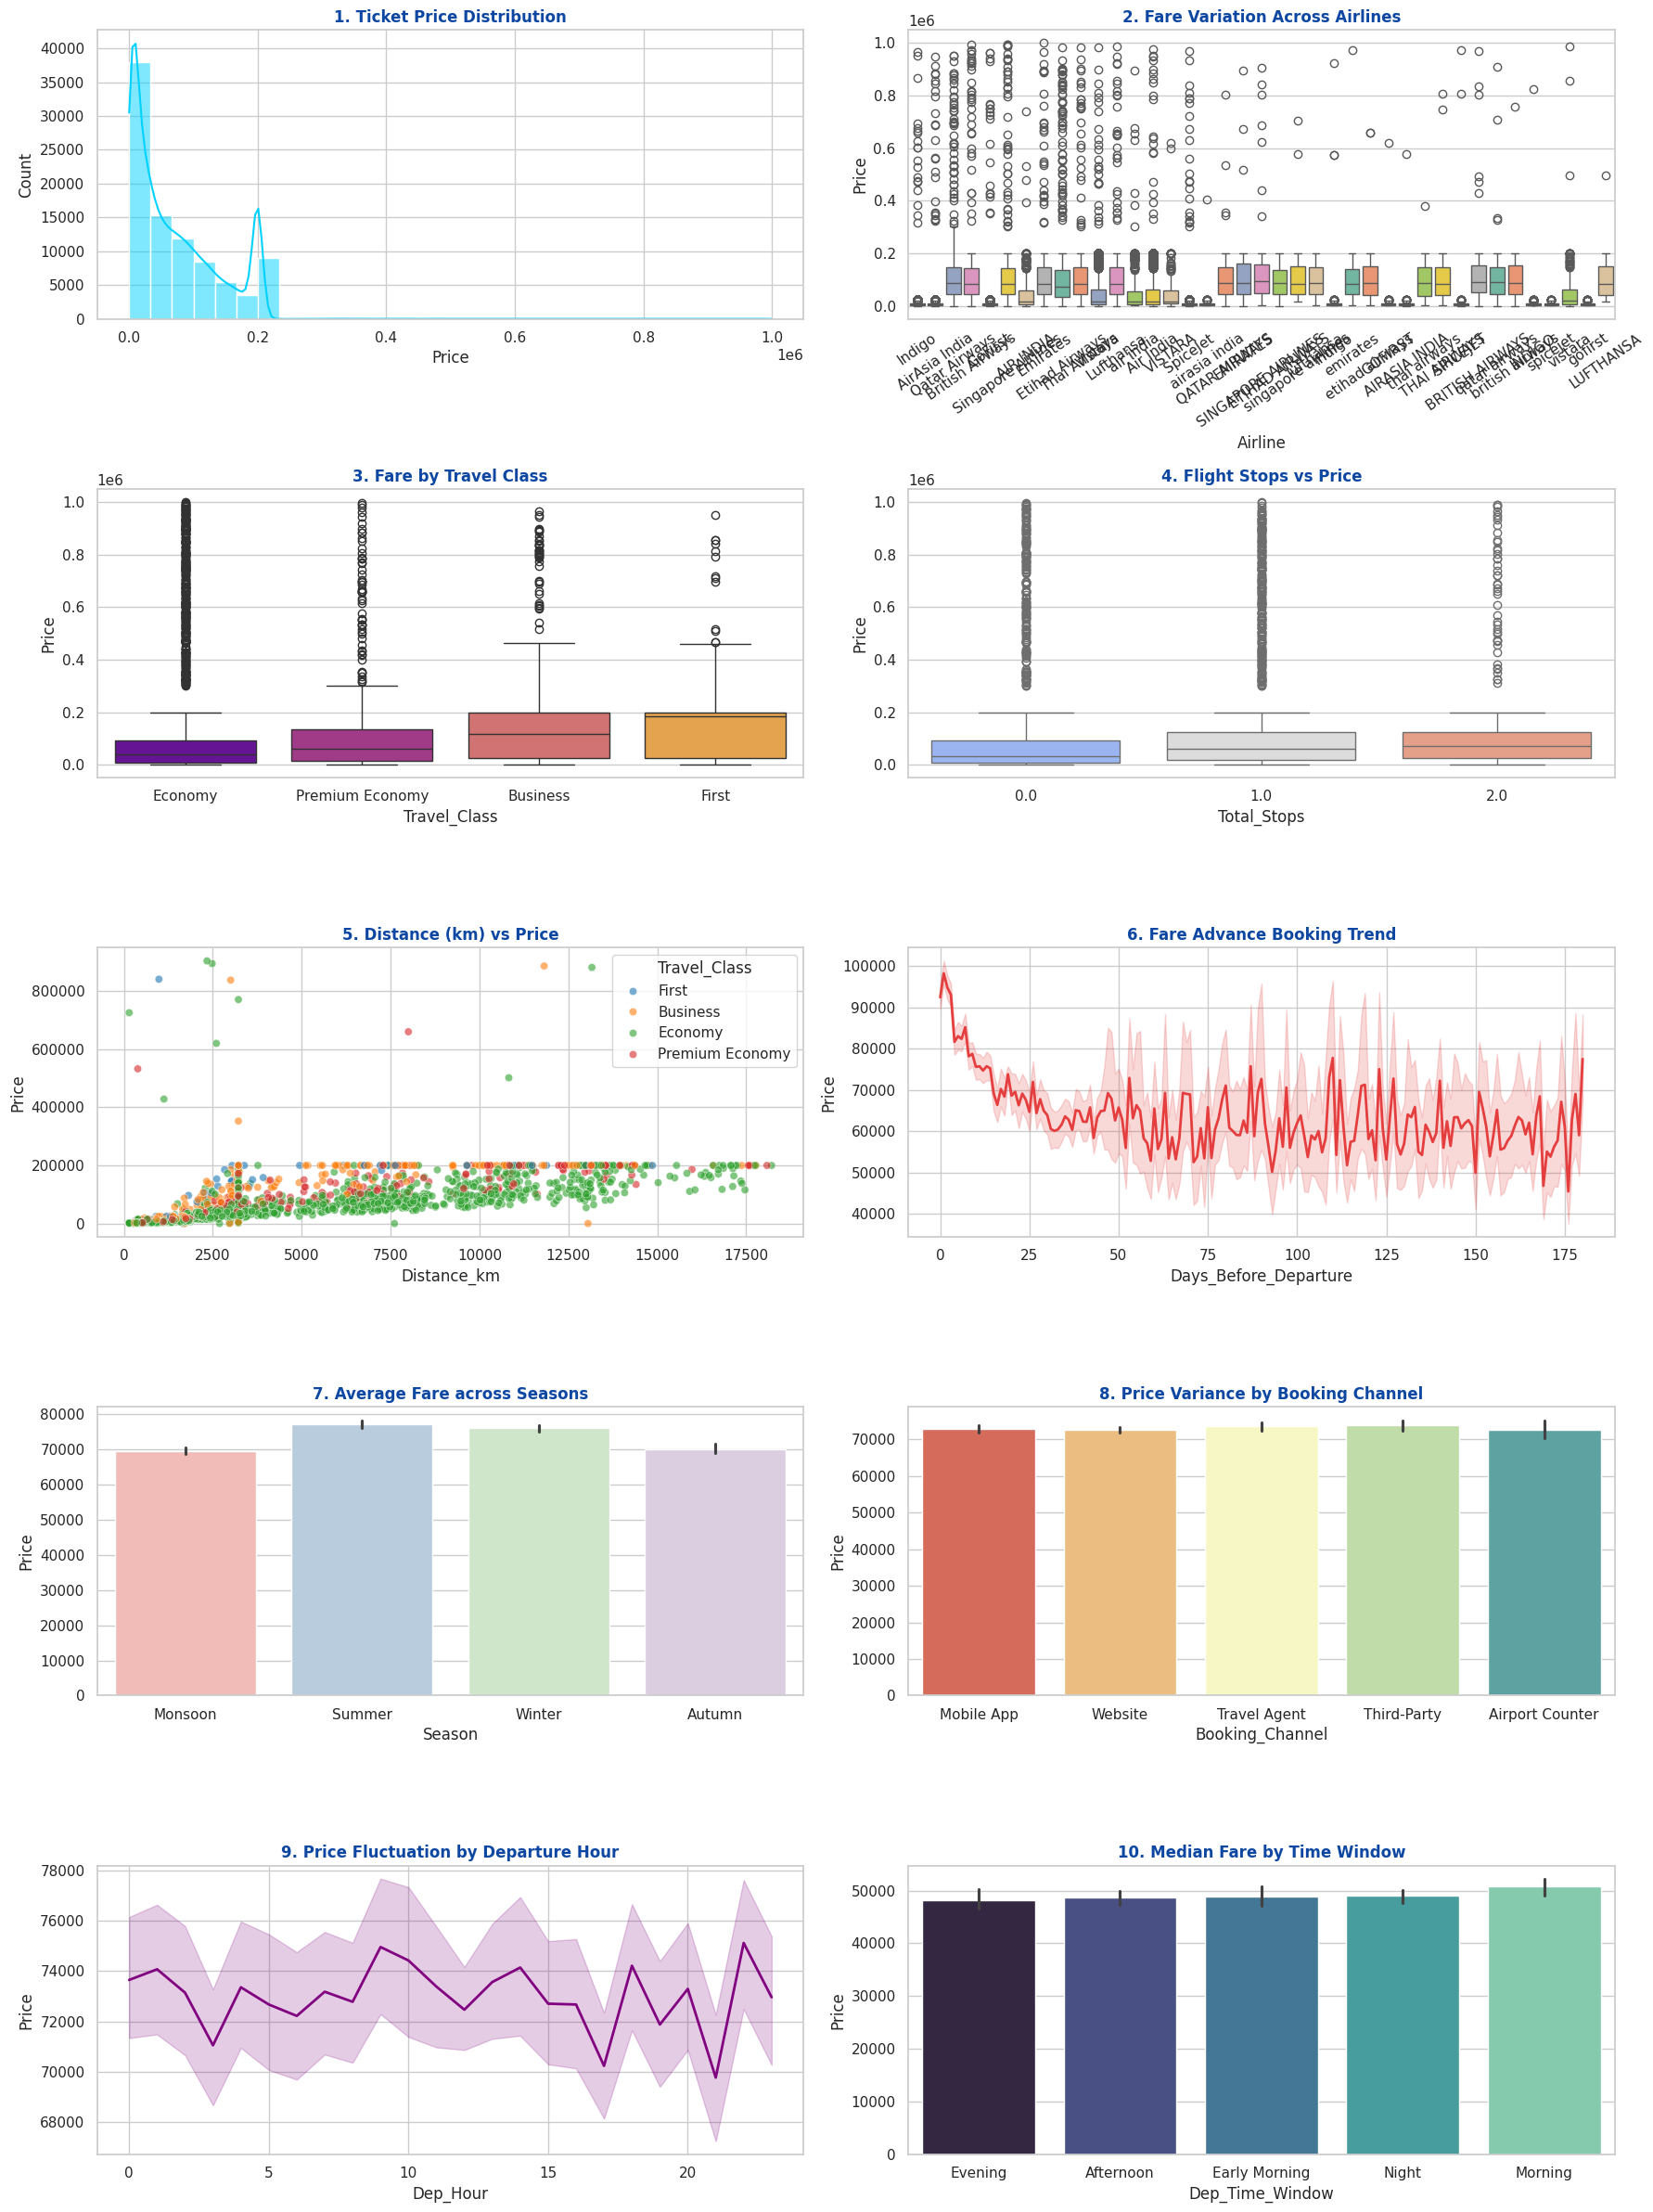

In [15]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(5, 2, figsize=(18, 24))

# 1. Price Distribution
sns.histplot(df['Price'], kde=True, ax=axes[0, 0], color='#00D2FF', bins=30)
axes[0, 0].set_title('1. Ticket Price Distribution', fontweight='bold', color='#0D47A1')

# 2. Airline vs Price
sns.boxplot(data=df, x='Airline', y='Price', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('2. Fare Variation Across Airlines', fontweight='bold', color='#0D47A1')
axes[0, 1].tick_params(axis='x', rotation=35)

# 3. Travel Class vs Price
sns.boxplot(data=df, x='Travel_Class', y='Price', ax=axes[1, 0], palette='plasma')
axes[1, 0].set_title('3. Fare by Travel Class', fontweight='bold', color='#0D47A1')

# 4. Total Stops Impact
sns.boxplot(data=df, x='Total_Stops', y='Price', ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('4. Flight Stops vs Price', fontweight='bold', color='#0D47A1')

# 5. Distance vs Price
sns.scatterplot(data=df.sample(2000, random_state=42), x='Distance_km', y='Price', hue='Travel_Class', ax=axes[2, 0], palette='tab10', alpha=0.6)
axes[2, 0].set_title('5. Distance (km) vs Price', fontweight='bold', color='#0D47A1')

# 6. Days Before Departure vs Price
sns.lineplot(data=df, x='Days_Before_Departure', y='Price', ax=axes[2, 1], color='#E53E3E', linewidth=2)
axes[2, 1].set_title('6. Fare Advance Booking Trend', fontweight='bold', color='#0D47A1')

# 7. Season vs Price
sns.barplot(data=df, x='Season', y='Price', ax=axes[3, 0], palette='Pastel1')
axes[3, 0].set_title('7. Average Fare across Seasons', fontweight='bold', color='#0D47A1')

# 8. Booking Channel Comparison
sns.barplot(data=df, x='Booking_Channel', y='Price', ax=axes[3, 1], palette='Spectral')
axes[3, 1].set_title('8. Price Variance by Booking Channel', fontweight='bold', color='#0D47A1')

# 9. Departure Hour Trend
sns.lineplot(data=df, x='Dep_Hour', y='Price', ax=axes[4, 0], color='purple', linewidth=2)
axes[4, 0].set_title('9. Price Fluctuation by Departure Hour', fontweight='bold', color='#0D47A1')

# 10. Time Window Median Price
sns.barplot(data=df, x='Dep_Time_Window', y='Price', estimator=np.median, ax=axes[4, 1], palette='mako')
axes[4, 1].set_title('10. Median Fare by Time Window', fontweight='bold', color='#0D47A1')

plt.tight_layout()
plt.savefig('viz_outputs/10_flight_charts.png', dpi=300)
plt.show()

In [8]:
#feature engineering
cat_cols = ['Airline', 'Source', 'Destination', 'Travel_Class', 'Season', 'Weekday', 'Aircraft_Type', 'Booking_Channel']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

drop_cols = ['Flight_ID', 'Departure_Date', 'Departure_Time', 'Arrival_Time', 'Duration', 'Dep_Time_Parsed', 'Arr_Time_Parsed', 'Dep_Time_Window', 'Price']
X = df_encoded.drop(columns=[c for c in drop_cols if c in df_encoded.columns])
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("--- MODEL EVALUATION METRICS ---")
print(f"Mean Absolute Error (MAE): ₹{mean_absolute_error(y_test, y_pred):.2f}")
print(f"Root Mean Squared Error (RMSE): ₹{np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R² Performance Score: {r2_score(y_test, y_pred):.4f}")

with open('model_artifacts/flight_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('model_artifacts/feature_columns.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

--- MODEL EVALUATION METRICS ---
Mean Absolute Error (MAE): ₹16097.84
Root Mean Squared Error (RMSE): ₹48408.95
R² Performance Score: 0.6152


In [9]:
from sklearn.metrics import r2_score

# accuracy on training data
y_train_pred = rf_model.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)

# accuracy on testing data
y_test_pred = rf_model.predict(X_test)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Training Data Accuracy (R² Score): {train_r2 * 100:.2f}%")
print(f"Testing Data Accuracy (R² Score):  {test_r2 * 100:.2f}%")

Training Data Accuracy (R² Score): 86.14%
Testing Data Accuracy (R² Score):  61.52%


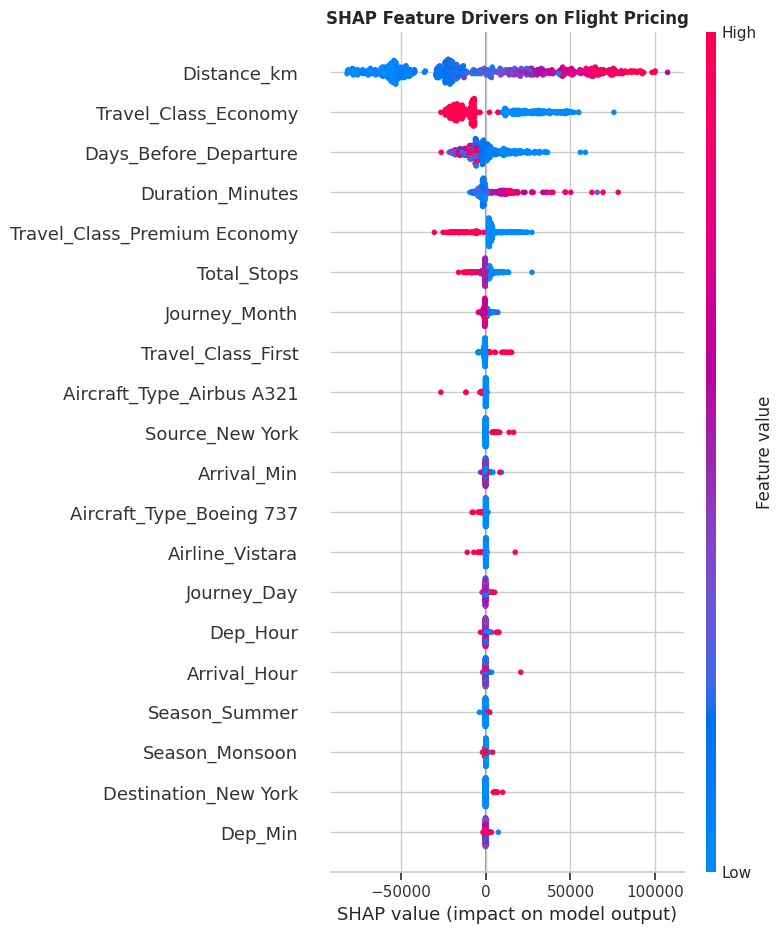

In [10]:
explainer = shap.TreeExplainer(rf_model)
sample_X = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(sample_X)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, sample_X, show=False)
plt.title("SHAP Feature Drivers on Flight Pricing", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_outputs/shap_summary_plot.png', dpi=300)
plt.show()

In [17]:
!curl -O https://raw.githubusercontent.com/https:/diyam08/AI-Travel-Analyst/main/app.py

import os
print("File exists:", os.path.exists('app.py'))

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    14  100    14    0     0     78      0 --:--:-- --:--:-- --:--:--    78
File exists: True


In [16]:
os.makedirs('model_artifacts', exist_ok=True)


with open('model_artifacts/flight_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)


with open('model_artifacts/feature_columns.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)


df.to_csv('model_artifacts/cleaned_flight_data.csv', index=False)

print(" Model artifacts successfully created in 'model_artifacts/' folder!")

 Model artifacts successfully created in 'model_artifacts/' folder!


In [18]:
joblib.dump(rf_model, 'model_artifacts/flight_model.pkl.gz', compress=3)


orig_size = os.path.getsize('model_artifacts/flight_model.pkl') / (1024 * 1024)
comp_size = os.path.getsize('model_artifacts/flight_model.pkl.gz') / (1024 * 1024)
print(f"Original Size: {orig_size:.2f} MB")
print(f"Compressed Size: {comp_size:.2f} MB")

Original Size: 61.08 MB
Compressed Size: 16.90 MB
